In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from SCIKIT.Lesson2 import Y_train

data = load_breast_cancer()

X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

y = pd.Series(
    data.target,
    name="target"
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [9]:
print(data.target_names)
print(y.value_counts())


['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [14]:
print(X.head())
#
# print("\nMissing values:")
# print(X.isnull().sum().sum())
#
# print("\nStatistics:")
# print(X.describe().T)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [17]:
print("\nMissing values:")
print(X.isnull().sum())
#
# print("\nStatistics:")
# print(X.describe().T)


Missing values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [18]:
print("\nStatistics:")
print(X.describe().T)


Statistics:
                         count        mean         std         min  \
mean radius              569.0   14.127292    3.524049    6.981000   
mean texture             569.0   19.289649    4.301036    9.710000   
mean perimeter           569.0   91.969033   24.298981   43.790000   
mean area                569.0  654.889104  351.914129  143.500000   
mean smoothness          569.0    0.096360    0.014064    0.052630   
mean compactness         569.0    0.104341    0.052813    0.019380   
mean concavity           569.0    0.088799    0.079720    0.000000   
mean concave points      569.0    0.048919    0.038803    0.000000   
mean symmetry            569.0    0.181162    0.027414    0.106000   
mean fractal dimension   569.0    0.062798    0.007060    0.049960   
radius error             569.0    0.405172    0.277313    0.111500   
texture error            569.0    1.216853    0.551648    0.360200   
perimeter error          569.0    2.866059    2.021855    0.757000   
area er

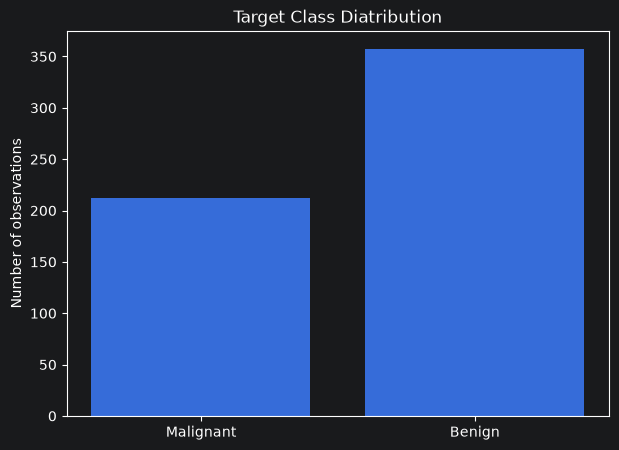

In [21]:
counts=y.value_counts().sort_index()
plt.figure(figsize=(7,5))
plt.bar(["Malignant"
        ,"Benign"],
counts.values,

)
plt.ylabel("Number of observations")
plt.title("Target Class Diatribution")
plt.show()

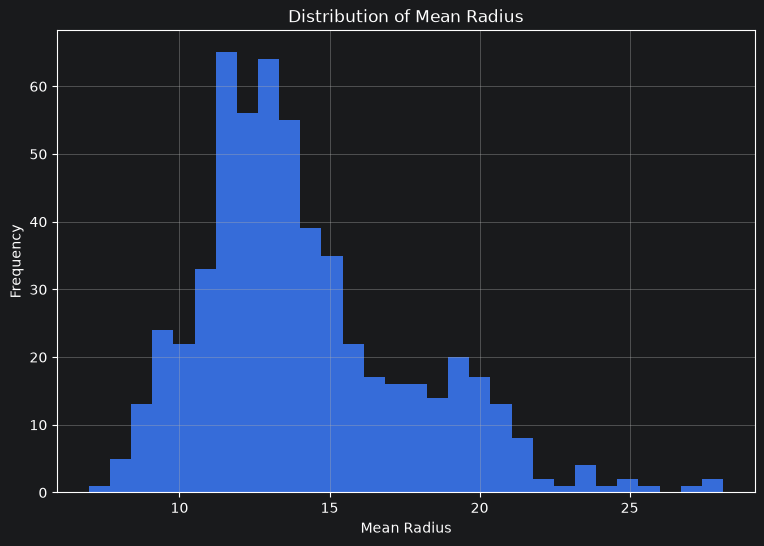

In [22]:
plt.figure(figsize=(9, 6))

plt.hist(
    X["mean radius"],
    bins=30
)

plt.xlabel("Mean Radius")
plt.ylabel("Frequency")

plt.title(
    "Distribution of Mean Radius"
)

plt.grid()

plt.show()

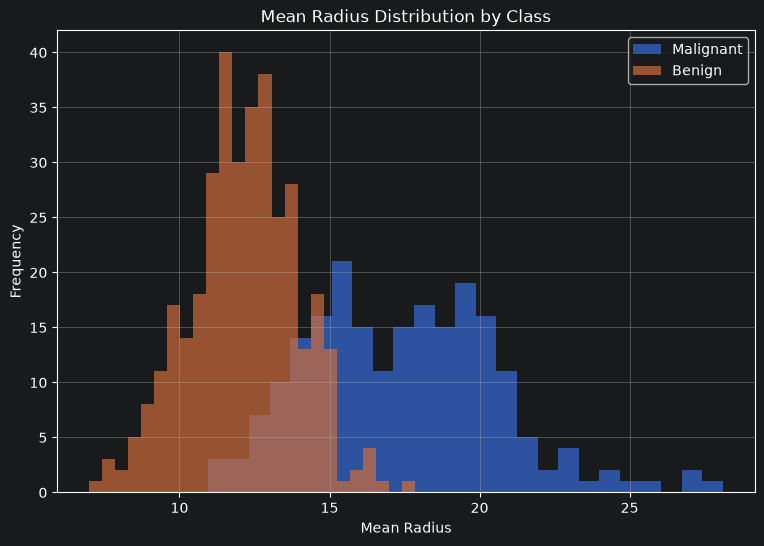

In [24]:
plt.figure(figsize=(9, 6))

plt.hist(
    X.loc[y == 0, "mean radius"],
    bins=25,
    alpha=0.7,
    label="Malignant"
)

plt.hist(
    X.loc[y == 1, "mean radius"],
    bins=25,
    alpha=0.7,
    label="Benign"
)

plt.xlabel("Mean Radius")
plt.ylabel("Frequency")

plt.title(
    "Mean Radius Distribution by Class"
)

plt.legend()
plt.grid()

plt.show()

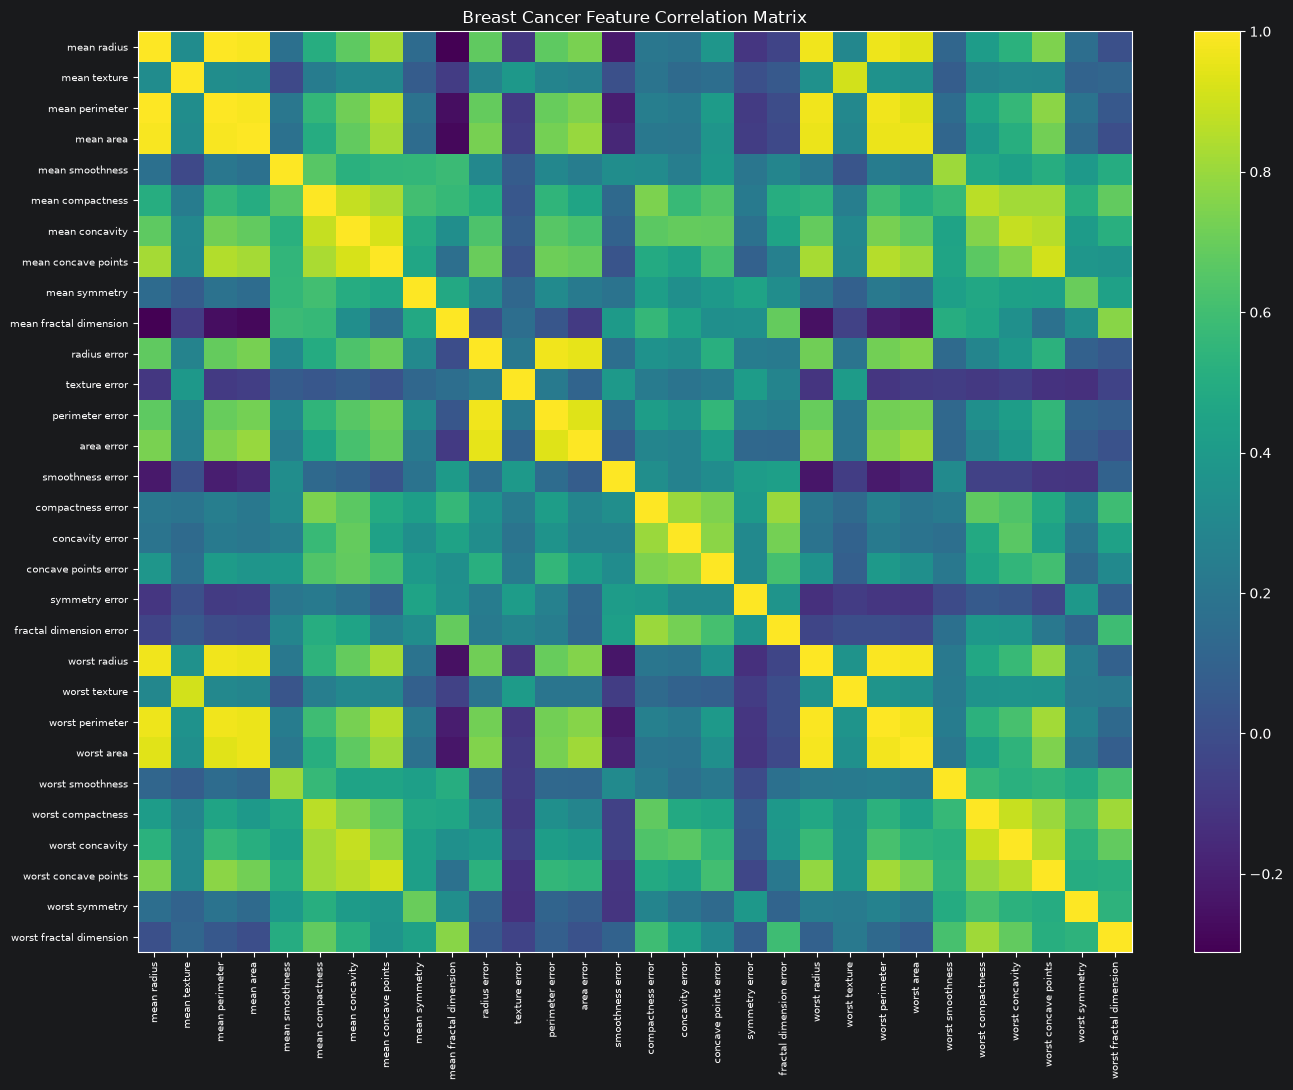

In [29]:
correlation = X.corr()

plt.figure(figsize=(14, 11))

plt.imshow(
    correlation,
    aspect="auto",


)

plt.colorbar()

plt.xticks(
    range(len(X.columns)),
    X.columns,
    rotation=90,
    fontsize=7
)

plt.yticks(
    range(len(X.columns)),
    X.columns,
    fontsize=7
)

plt.title(
    "Breast Cancer Feature Correlation Matrix"
)

plt.tight_layout()

plt.show()

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (455, 30)
Testing : (114, 30)


In [32]:
from xgboost import XGBClassifier
xgb_model=XGBClassifier(
    n_estimators=500,
    learning_rate=0.3,
    max_depth=3,
min_child_weight=2,
subsample=0.8,
colsample_bytree=0.8,
reg_alpha=0.1,
reg_lambda=1.0,
objective="binary:logistic",
eval_metric="logloss",
early_stopping_rounds=50,
random_state=42




)

In [34]:
xgb_model.fit(
    X_train,y_train,
    eval_set=[(X_test, y_test)],


    verbose=False,



)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [36]:
y_pred=xgb_model.predict(X_test)
y_prob=xgb_model.predict_proba(X_test)[:,1]


In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1 Score : 0.9655
ROC-AUC  : 0.9937


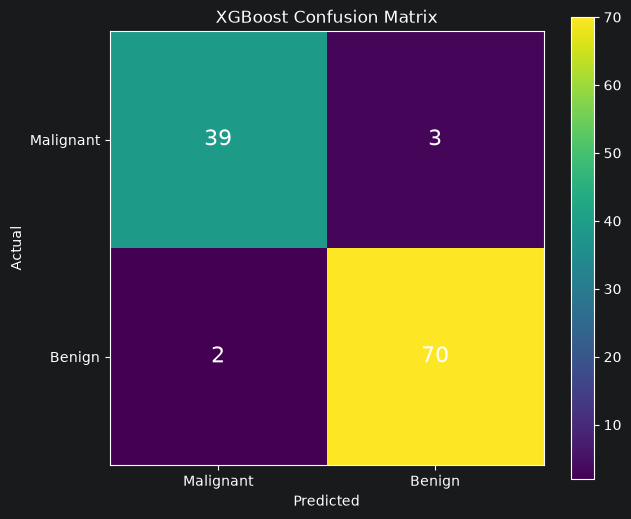

In [39]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.colorbar()

plt.xticks(
    [0, 1],
    ["Malignant", "Benign"]
)

plt.yticks(
    [0, 1],
    ["Malignant", "Benign"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("XGBoost Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=16
        )

plt.show()

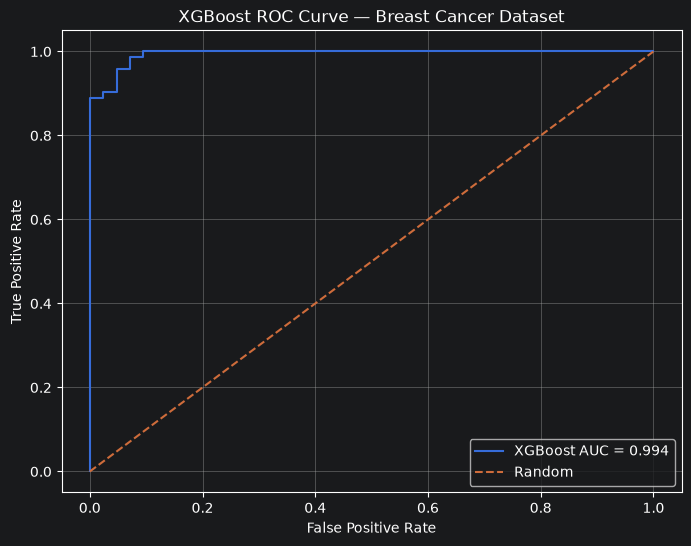

In [40]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost AUC = {auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "XGBoost ROC Curve — Breast Cancer Dataset"
)

plt.legend()
plt.grid()

plt.show()

In [41]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
20,worst radius,0.253228
22,worst perimeter,0.212089
7,mean concave points,0.154863
27,worst concave points,0.099559
26,worst concavity,0.087572
23,worst area,0.044490
3,mean area,0.016885
1,mean texture,0.016277
24,worst smoothness,0.014329
4,mean smoothness,0.012560


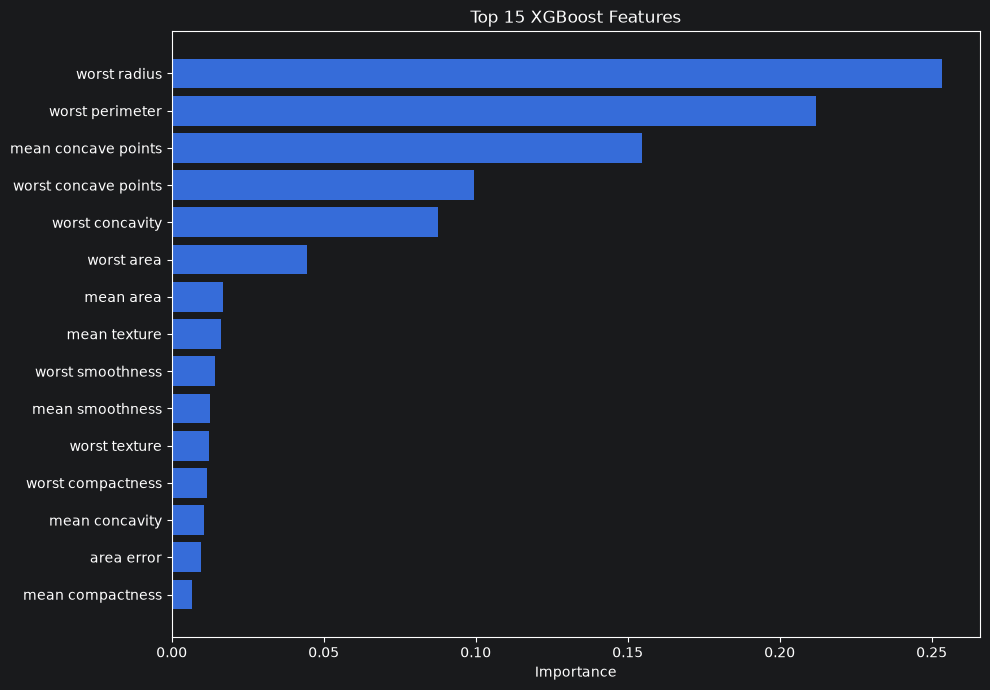

In [42]:
top_features = importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")

plt.title(
    "Top 15 XGBoost Features"
)

plt.tight_layout()

plt.show()

In [43]:
from sklearn.model_selection import train_test_split

# First: separate the final test set
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Second: create validation set
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=42
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (364, 30)
Validation: (91, 30)
Test: (114, 30)


In [44]:
from xgboost import XGBClassifier

baseline = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    early_stopping_rounds=40,
    random_state=42
)

In [45]:
baseline.fit(
    X_train,
    y_train,
    eval_set=[
        (X_val, y_val)
    ],
    verbose=False
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",40
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [46]:
print(
    "Best iteration:",
    baseline.best_iteration
)

print(
    "Best validation score:",
    baseline.best_score
)

Best iteration: 217
Best validation score: 0.1305910104317693


In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

baseline_pred = baseline.predict(X_test)

baseline_prob = baseline.predict_proba(
    X_test
)[:, 1]

baseline_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        baseline_pred
    ),

    "Precision": precision_score(
        y_test,
        baseline_pred
    ),

    "Recall": recall_score(
        y_test,
        baseline_pred
    ),

    "F1": f1_score(
        y_test,
        baseline_pred
    ),

    "ROC-AUC": roc_auc_score(
        y_test,
        baseline_prob
    )
}

for metric, value in baseline_metrics.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.9474
Precision: 0.9583
Recall: 0.9583
F1: 0.9583
ROC-AUC: 0.9897


In [48]:
param_distributions = {
    "max_depth": [2, 3, 4, 5, 6],

    "min_child_weight": [1, 2, 3, 5, 7],

    "gamma": [0, 0.1, 0.2, 0.5],

    "subsample": [0.7, 0.8, 0.9, 1.0],

    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],

    "learning_rate": [
        0.01,
        0.03,
        0.05,
        0.1
    ],

    "reg_alpha": [
        0,
        0.01,
        0.1,
        1
    ],

    "reg_lambda": [
        0.5,
        1,
        2,
        5
    ]
}
from sklearn.model_selection import RandomizedSearchCV

search_model = XGBClassifier(
    n_estimators=500,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=1
)

In [49]:
from sklearn.model_selection import RandomizedSearchCV

search_model = XGBClassifier(
    n_estimators=500,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=1
)

In [50]:
random_search = RandomizedSearchCV(
    estimator=search_model,
    param_distributions=param_distributions,

    n_iter=30,

    scoring="roc_auc",

    cv=5,

    random_state=42,

    n_jobs=-1,

    verbose=1
)

In [51]:
random_search.fit(
    X_train_full,
    y_train_full
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [2, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichretu

In [52]:
print(
    "Best Parameters:"
)

for parameter, value in random_search.best_params_.items():
    print(
        f"{parameter}: {value}"
    )

Best Parameters:
subsample: 0.7
reg_lambda: 1
reg_alpha: 0.01
min_child_weight: 1
max_depth: 2
learning_rate: 0.01
gamma: 0
colsample_bytree: 1.0


In [53]:
print(
    "\nBest CV ROC-AUC:",
    random_search.best_score_
)


Best CV ROC-AUC: 0.9897832817337461


In [54]:
tuned_model = random_search.best_estimator_

In [55]:
tuned_pred = tuned_model.predict(
    X_test
)

tuned_prob = tuned_model.predict_proba(
    X_test
)[:, 1]

In [56]:
tuned_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        tuned_pred
    ),

    "Precision": precision_score(
        y_test,
        tuned_pred
    ),

    "Recall": recall_score(
        y_test,
        tuned_pred
    ),

    "F1": f1_score(
        y_test,
        tuned_pred
    ),

    "ROC-AUC": roc_auc_score(
        y_test,
        tuned_prob
    )
}

In [58]:
comparison = pd.DataFrame({
    "Baseline": baseline_metrics,
    "Tuned": tuned_metrics
})

print(comparison)

           Baseline     Tuned
Accuracy   0.947368  0.964912
Precision  0.958333  0.959459
Recall     0.958333  0.986111
F1         0.958333  0.972603
ROC-AUC    0.989749  0.994048


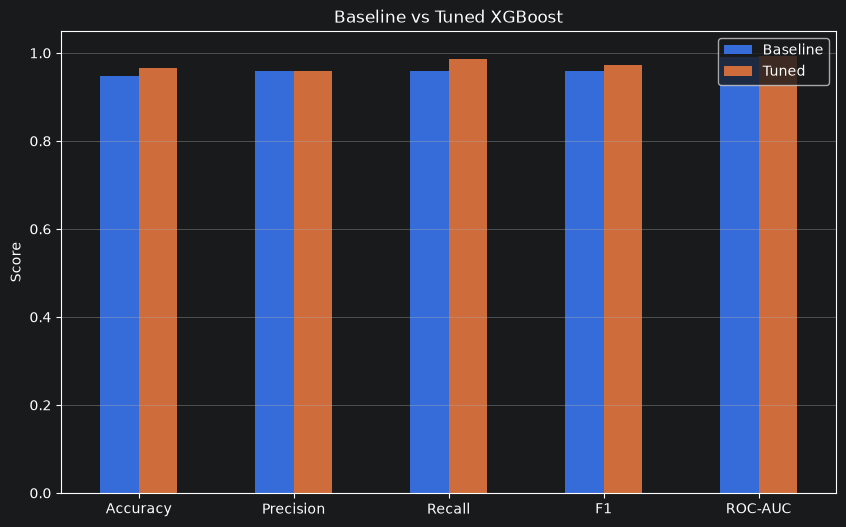

In [59]:
comparison.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylim(0, 1.05)

plt.ylabel("Score")

plt.title(
    "Baseline vs Tuned XGBoost"
)

plt.xticks(
    rotation=0
)

plt.grid(
    axis="y"
)

plt.show()

In [60]:
cv_results = pd.DataFrame(
    random_search.cv_results_
)

cv_results[
    [
        "mean_test_score",
        "std_test_score",
        "param_max_depth",
        "param_learning_rate",
        "param_subsample"
    ]
].sort_values(
    "mean_test_score",
    ascending=False
).head(10)

,mean_test_score,std_test_score,param_max_depth,param_learning_rate,param_subsample
2,0.989783,0.014691,2,0.01,0.7
25,0.989783,0.016328,2,0.05,0.7
14,0.989680,0.017123,4,0.01,0.8
22,0.989680,0.016866,3,0.03,0.8
18,0.989680,0.016014,4,0.05,0.8
6,0.989577,0.018297,3,0.10,0.9
13,0.989370,0.016459,4,0.01,0.7
5,0.989164,0.017839,4,0.10,0.9
12,0.988958,0.019344,2,0.05,0.8
9,0.988854,0.019511,5,0.03,1.0


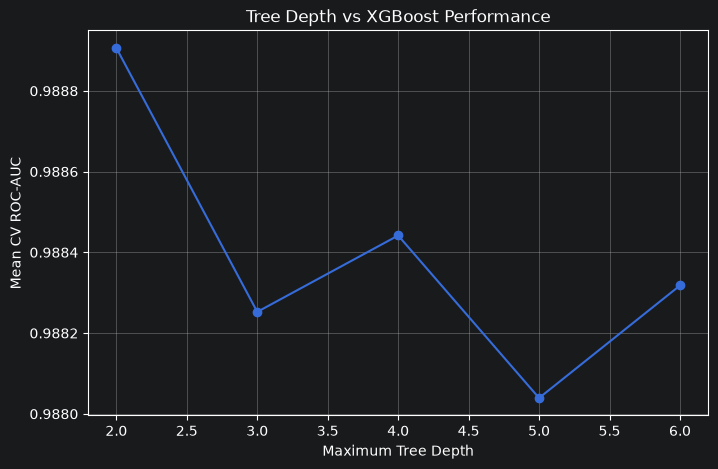

In [61]:
depth_analysis = (
    cv_results
    .groupby("param_max_depth")["mean_test_score"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.plot(
    depth_analysis.index.astype(int),
    depth_analysis.values,
    marker="o"
)

plt.xlabel("Maximum Tree Depth")

plt.ylabel("Mean CV ROC-AUC")

plt.title(
    "Tree Depth vs XGBoost Performance"
)

plt.grid()

plt.show()

In [62]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [64]:
explainer = shap.TreeExplainer(
    tuned_model
)

In [65]:
shap_values = explainer.shap_values(
    X_test
)

print(
    np.array(shap_values).shape
)

(114, 30)


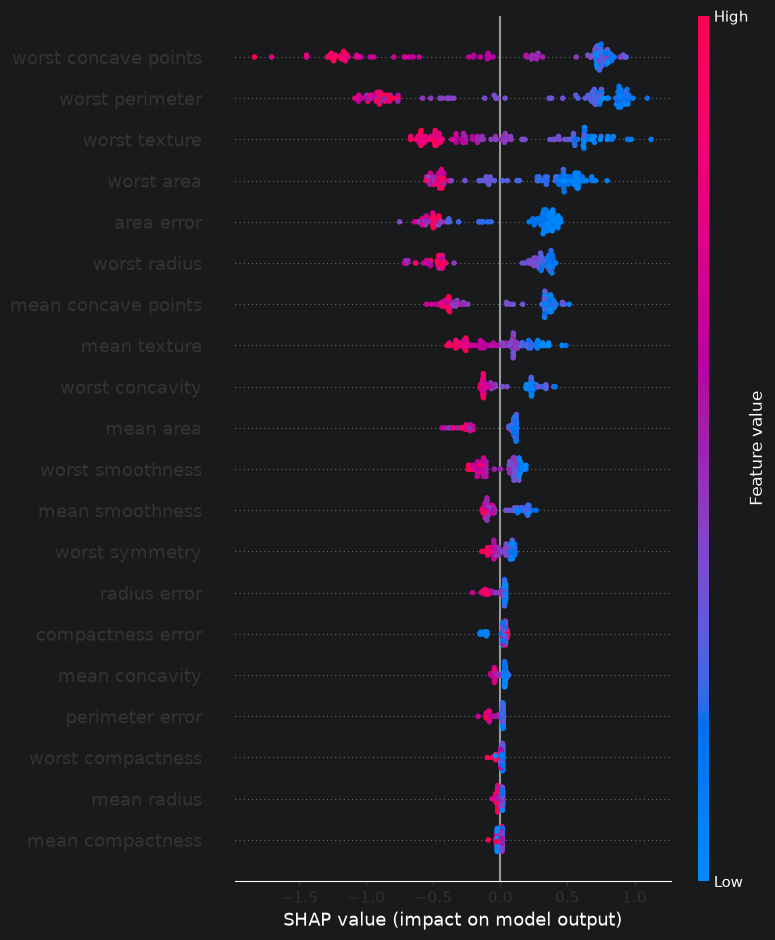

In [66]:
shap.summary_plot(
    shap_values,
    X_test
)

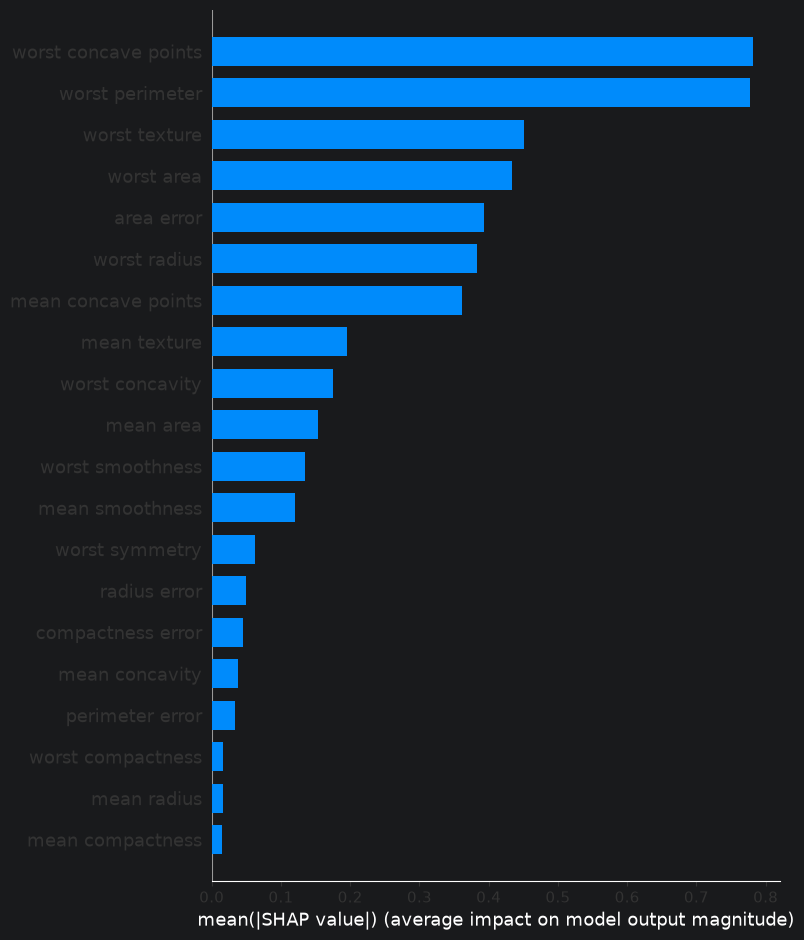

In [67]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [68]:
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

print(
    shap_importance.head(10)
)

                 Feature  Importance
27  worst concave points    0.781583
22       worst perimeter    0.777351
21         worst texture    0.450472
23            worst area    0.434098
13            area error    0.393817
20          worst radius    0.382831
7    mean concave points    0.361596
1           mean texture    0.195298
26       worst concavity    0.174645
3              mean area    0.152970


In [70]:
sample_index = 10
sample = X_test.iloc[
    sample_index
]

print(sample)
sample = X_test.iloc[
    sample_index
]

print(sample)
print(
    "Actual:",
    y_test.iloc[sample_index]
)
print(
    "Predicted:",
    tuned_pred[sample_index]
)
print(
    "Probability:",
    tuned_prob[sample_index]
)

mean radius                 12.950000
mean texture                16.020000
mean perimeter              83.140000
mean area                  513.700000
mean smoothness              0.100500
mean compactness             0.079430
mean concavity               0.061550
mean concave points          0.033700
mean symmetry                0.173000
mean fractal dimension       0.064700
radius error                 0.209400
texture error                0.763600
perimeter error              1.231000
area error                  17.670000
smoothness error             0.008725
compactness error            0.020030
concavity error              0.023350
concave points error         0.011320
symmetry error               0.026250
fractal dimension error      0.004726
worst radius                13.740000
worst texture               19.930000
worst perimeter             88.810000
worst area                 585.400000
worst smoothness             0.148300
worst compactness            0.206800
worst concav

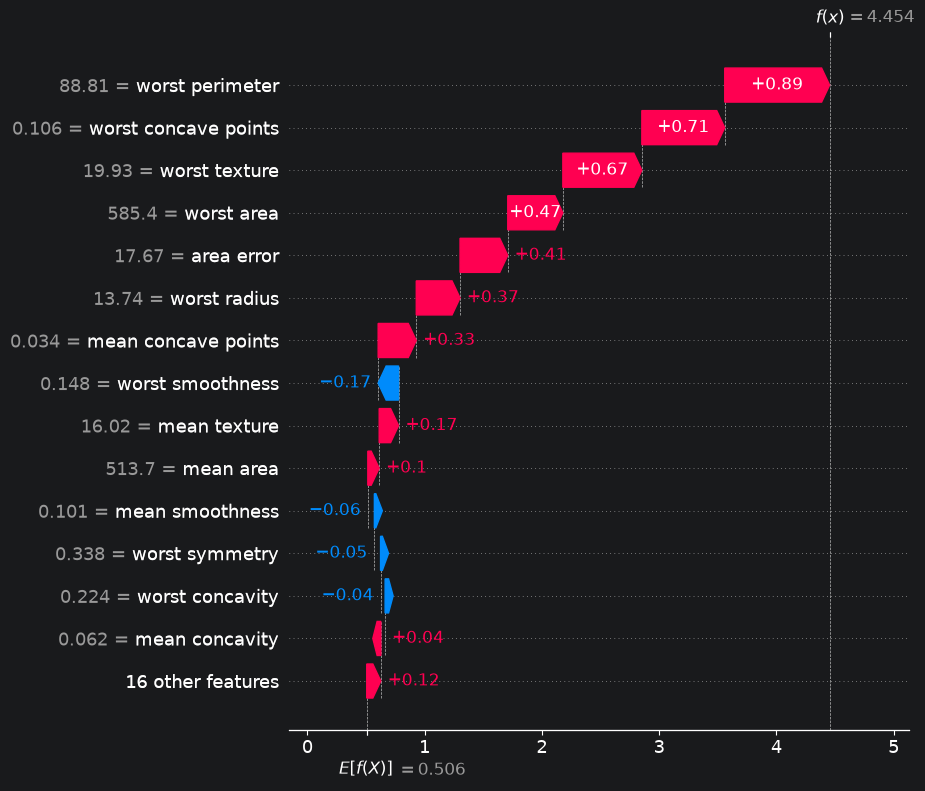

In [71]:
sample_shap = shap_values[
    sample_index
]

explanation = shap.Explanation(
    values=sample_shap,
    base_values=explainer.expected_value,
    data=sample.values,
    feature_names=X_test.columns
)

shap.plots.waterfall(
    explanation,
    max_display=15
)

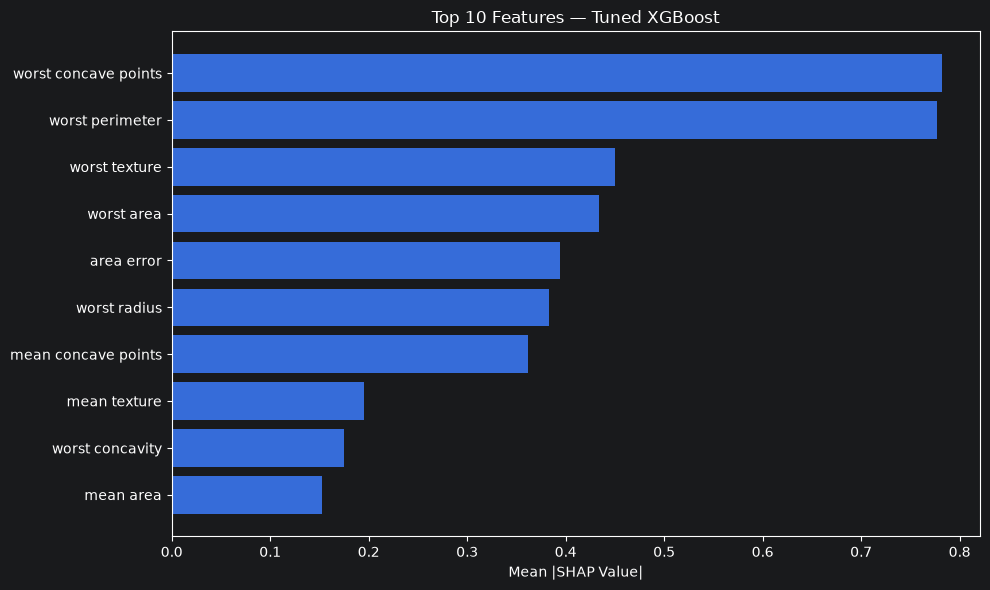

In [72]:
top_10 = shap_importance.head(10)

top_10.reset_index(
    drop=True,
    inplace=True
)

top_10

